Project 1

Team: Shuban Iyer(shubani2), Yogi Patel(ypate68), Swarit(put your netid here)

In [83]:
#Currently opening the pickle file using rb and load in order to not edit the data set.
#Need to have the proper imports needed to import from pkle 
#Also want to import numpy in order to help with list functions

import pickle as pkl
import pandas as pd
import matplotlib.pyplot as plt

loaded = pkl.load(open('delta_a100_gpu_xid_dataset.pkl', 'rb'))

In [84]:
# Then using loaded, we would like to parse through to find XID errors observed on March 10th, 2024
# XID errors are stored in a list, so can use len to find the number of elements in it
# We also want to find the list of unique XID 
march_10 = loaded['2024-03-10']
print("Number of XID Errors: ", len(march_10)) # this gives us the amount of XID errors for that date

unique_errors = list({errors['XID'] for errors in march_10})
print("Unique XID Errors: ", unique_errors)

Number of XID Errors:  87
Unique XID Errors:  [74, 43, 45, 13, 119, 31]


In [85]:
# creating pandas dataframe to access data
rows = []

# flattening logs down to rows for the dataframe
for date, logs in loaded.items():
    for log in logs:
        entry_row = {
            'Date': date,
            'Datetime': log.get('datetime'),
            'Timestamp': log.get('timestamp'),
            'Node name': log.get('node_name'),
            'Device ID': log.get('device_id'),
            'XID': log.get('XID'),
            'Tag': log.get('Tag')
        }
        rows.append(entry_row)

dataframe = pd.DataFrame(rows)

# sorting dataframe according to 'Timestamp' in increasing order
# 1. first need to cast each 'Timestamp' value as an integer 
# 2. sort by new 'Timestamp' column value

dataframe['Timestamp'] = pd.to_numeric(dataframe['Timestamp'])
dataframe = dataframe.sort_values(by='Timestamp', ascending=True)

# Task 0 completed


In [86]:
top_ten_rows = dataframe.head(10)
print("Top 10 Rows in Dataframe")
display(top_ten_rows)

first_unix = dataframe.head(1)['Timestamp'].values
first_datetime =  dataframe.head(1)['Datetime'].values

print("First UNIX Timestamp:", first_unix)
print("First Human-readable Datetime:", first_datetime)
# 1.1 completed


Top 10 Rows in Dataframe


,Date,Datetime,Timestamp,Node name,Device ID,XID,Tag
0,2022-07-17,2022-07-17T10:27:27.422837-05:00,1.658072e+09,gpua088,0000:c7:00,119,119_GSP_RPC_timeout
1,2022-07-17,2022-07-17T10:29:29.304632-05:00,1.658072e+09,gpua048,0000:07:00,45,045_GPU_PREEMPTIVE_CLEANUP
2,2022-07-17,2022-07-17T11:03:11.093546-05:00,1.658074e+09,gpua001,0000:85:00,13,013_GPU_GRAPHIC_ENGINE_EXCEPTION
3,2022-07-17,2022-07-17T11:04:15.807907-05:00,1.658074e+09,gpua044,0000:85:00,13,013_GPU_GRAPHIC_ENGINE_EXCEPTION
4,2022-07-17,2022-07-17T11:10:53.818266-05:00,1.658074e+09,gpua045,0000:07:00,43,043_GPU_STOPPED_PROCESSING
5,2022-07-17,2022-07-17T11:16:30.534940-05:00,1.658075e+09,gpua001,0000:c7:00,13,013_GPU_GRAPHIC_ENGINE_EXCEPTION
6,2022-07-17,2022-07-17T11:27:40.849346-05:00,1.658075e+09,gpua001,0000:c7:00,13,013_GPU_GRAPHIC_ENGINE_EXCEPTION
7,2022-07-17,2022-07-17T12:10:20.898006-05:00,1.658078e+09,gpua072,0000:85:00,13,013_GPU_GRAPHIC_ENGINE_EXCEPTION
8,2022-07-17,2022-07-17T13:21:30.008143-05:00,1.658082e+09,gpua081,0000:85:00,13,013_GPU_GRAPHIC_ENGINE_EXCEPTION
9,2022-07-17,2022-07-17T13:21:34.279469-05:00,1.658082e+09,gpua005,0000:c7:00,13,013_GPU_GRAPHIC_ENGINE_EXCEPTION


First UNIX Timestamp: [1.65807165e+09]
First Human-readable Datetime: ['2022-07-17T10:27:27.422837-05:00']


In [87]:
n = len(dataframe) # total entries
ct_43 = len(dataframe[dataframe['XID'] == 43])
ct_119 = len(dataframe[dataframe['XID'] == 119])

print("1.2a Probability of XID 43, P(XID 43):", ct_43/n)
print("1.2b Probability of XID 119, P(XID 119):", ct_119/n)
print("1.2c: Since P(XID 43) > P(XID 119), the system is significantly more likely to encounter user errors.")
# completed 1.2c

1.2a Probability of XID 43, P(XID 43): 0.11687569714612182
1.2b Probability of XID 119, P(XID 119): 0.017724515058356233
1.2c: Since P(XID 43) > P(XID 119), the system is significantly more likely to encounter user errors.


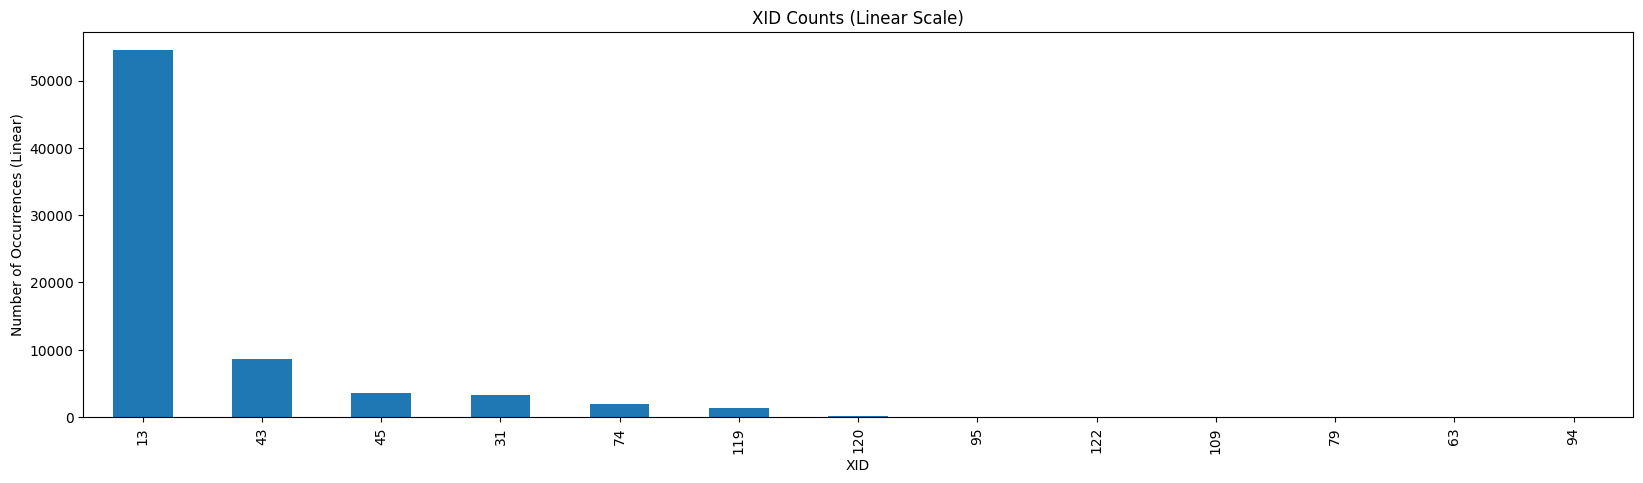

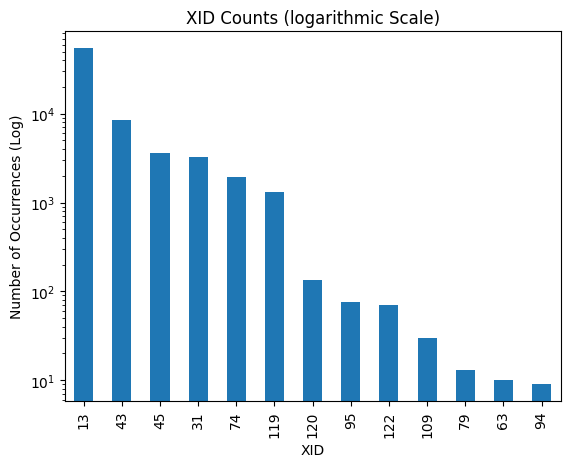

In [101]:
# first sort all XID's by the amount of times they appear
sorted_xid = dataframe['XID'].value_counts().sort_values(ascending=False)

plt.figure(figsize=(20, 5))

# linear scale
sorted_xid.plot(kind='bar')
plt.title('XID Counts (Linear Scale)')
plt.xlabel('XID')
plt.ylabel('Number of Occurrences (Linear)')
plt.show()

# logarithmic scale
sorted_xid.plot(kind='bar')
plt.yscale('log')
plt.title('XID Counts (logarithmic Scale)')
plt.xlabel('XID')
plt.ylabel('Number of Occurrences (Log)')
plt.show()